In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [68]:
url_ibcbr = 'https://api.bcb.gov.br/dados/serie/bcdata.sgs.24363/dados?formato=json&dataInicial=01/01/2003&dataFinal=01/12/2025'
url_pib = 'https://api.bcb.gov.br/dados/serie/bcdata.sgs.22099/dados?formato=json&dataInicial=01/01/2003&dataFinal=01/12/2025'

In [80]:
df_ibcbr = pd.read_json(url_ibcbr)
df_pib = pd.read_json(url_pib)

In [81]:
tri = ['1° tri. ', '2° tri. ', '3° tri. ', '4° tri. ']
ano = 2003
ind = []

while ano != 2026:
    for i in tri:
        ind.append(f'{i}{ano}')
    ano += 1

In [82]:
df_ibcbr['data'] = pd.to_datetime(df_ibcbr['data'], dayfirst = True)
df_ibcbr = df_ibcbr.set_index('data')
df_ibcbr = df_ibcbr.resample('QE').mean()
df_ibcbr['Trimestre'] = ind
df_ibcbr = df_ibcbr.set_index('Trimestre')

df_pib['data'] = pd.to_datetime(df_pib['data'], dayfirst = True)
df_pib = df_pib.set_index('data')
df_pib['Trimestre'] = ind
df_pib = df_pib.set_index('Trimestre')

In [ ]:
df_comb = pd.concat([df_ibcbr, df_pib], axis = 1)
df_comb.columns.values[0] = 'IBC-Br'
df_comb.columns.values[1] = 'PIB'

In [98]:
df_comb['Var. % (IBC-Br)'] = (df_comb['IBC-Br'].pct_change() * 100).round(2)
df_comb['Var. % (PIB)'] = (df_comb['PIB'].pct_change() * 100).round(2)
df_comb['Dif. (%IBC-Br - %PIB)'] = df_comb['Var. % (IBC-Br)'] - df_comb['Var. % (PIB)']

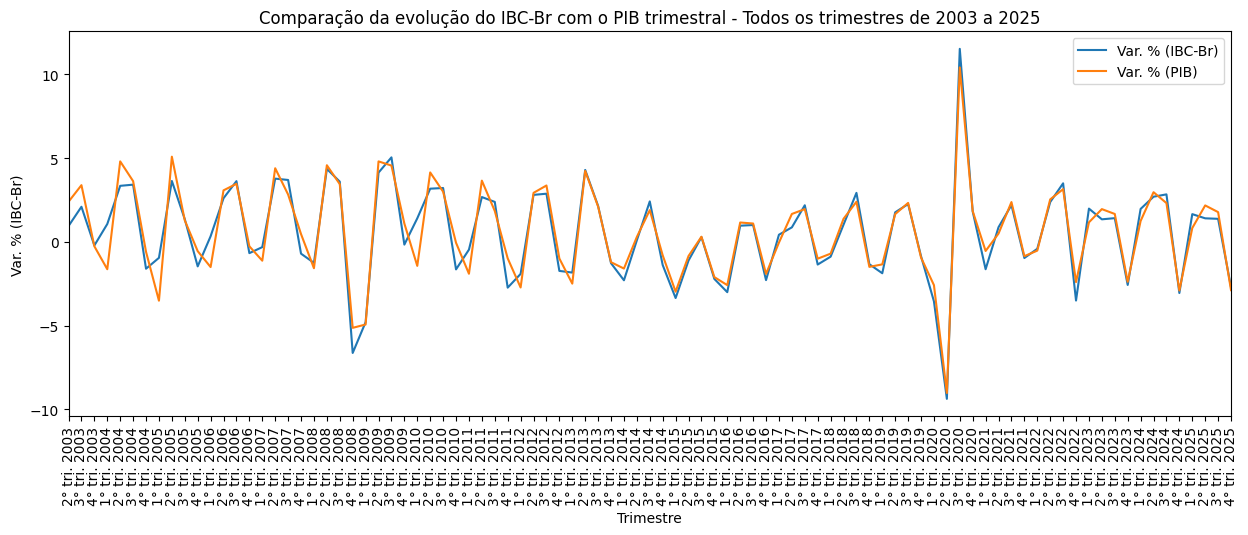

In [115]:
fig, ax = plt.subplots(figsize=(15,5))

sns.lineplot(data = df_comb, x = df_comb.index , y = 'Var. % (IBC-Br)', label = 'Var. % (IBC-Br)')
sns.lineplot(data = df_comb, x = df_comb.index , y = 'Var. % (PIB)', label = 'Var. % (PIB)')

plt.margins(x=0)
plt.title('Comparação da evolução do IBC-Br com o PIB trimestral - Todos os trimestres de 2003 a 2025')

ax.tick_params(axis="x", rotation=90)

plt.show()

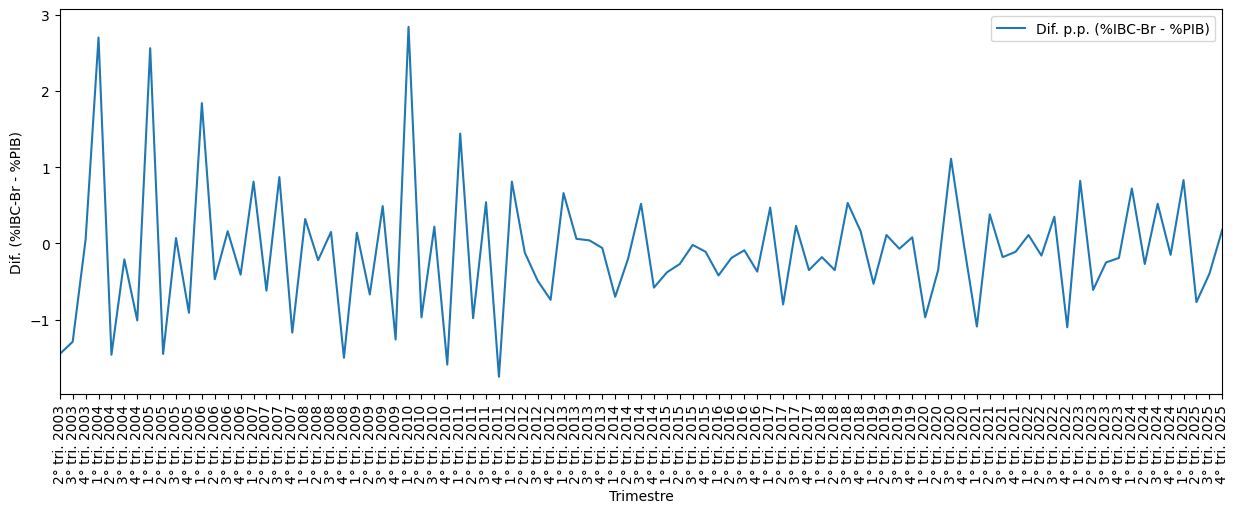

In [114]:
fig, ax = plt.subplots(figsize=(15,5))

sns.lineplot(data = df_comb, x = df_comb.index , y = 'Dif. (%IBC-Br - %PIB)', label = 'Dif. p.p. (%IBC-Br - %PIB)')

plt.margins(x=0)

ax.tick_params(axis="x", rotation=90)

plt.show()